# DD2421 Machine Learning: Programming Challenge
This notebook builds and trains different classifiers on a labeled dataset, and then uses it to infer the labels of an unlabeled evaluation dataset.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


2025-10-14 19:23:39.077004: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load data

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('TrainOnMe_orig.csv')
eval_df = pd.read_csv('EvaluateOnMe.csv')

train_df.head()


,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13
0,Jorgsuto,99.62776,-0.74730,-106.04085,-1.21694,199.59889,-88.84034,Slängpolskorgris,1.36603,2.62967,12.17710,-3.38007,True,445.11836
1,Andjorg,100.22296,0.85161,-98.91119,-1.23724,200.19240,-89.88662,Polkagris,-2.23901,0.65370,10.72266,-2.38136,True,451.65919
2,Andsuto,100.12711,0.22396,-96.58029,-1.18725,200.10113,-89.18542,Polkagris,0.38295,-0.58657,12.60082,-1.28045,True,452.34540
3,Jorgsuto,100.81843,0.02120,-102.78871,-1.26271,200.78442,-92.00700,Polkagris,-0.28207,0.81744,13.57450,0.12083,True,452.69780
4,Jorgsuto,101.07489,1.18863,-101.29639,-1.23077,201.04424,-92.83613,Schottisgris,1.31717,0.69887,12.50238,-0.71997,True,454.72627


### Exploratory Data Analysis
We'll take a look at the dataset to understand its structure, distributions, and potential issues before preprocessing.


In [3]:
""" Notas extras para futuros analasis:

- comprobar NaN ...
- df.describe(): par ver mx,min,varimza, media...
- plotear boxplots para ver ouliers 
- SMOTE buena practica si hay clases desbalanceadas ()

* q aplicar sobre el test y q no para mantenrlo `virgen´:

SMOTE u otros métodos de oversampling/undersampling → SOLO en training.
Normalización / estandarización (scaler.fit) → Ajustar solo con training, luego aplicar (transform) al test.
Reducción de dimensionalidad (PCA, LDA, etc.) → Ajustar con training (fit), aplicar con test (transform).
Outliers si los ajusto en el training, en el test ajustar con los valores aprendidos.
Codificacion d variables → fit y luego transformación.
Eliminacion d atributos → manualmente en ambas (drop)
"""

' Notas extras para futuros analasis:\n\n- comprobar NaN ...\n- df.describe(): par ver mx,min,varimza, media...\n- plotear boxplots para ver ouliers \n- SMOTE buena practica si hay clases desbalanceadas ()\n\n* q aplicar sobre el test y q no para mantenrlo `virgen´:\n\nSMOTE u otros métodos de oversampling/undersampling → SOLO en training.\nNormalización / estandarización (scaler.fit) → Ajustar solo con training, luego aplicar (transform) al test.\nReducción de dimensionalidad (PCA, LDA, etc.) → Ajustar con training (fit), aplicar con test (transform).\nOutliers si los ajusto en el training, en el test ajustar con los valores aprendidos.\nCodificacion d variables → fit y luego transformación.\nEliminacion d atributos → manualmente en ambas (drop)\n'

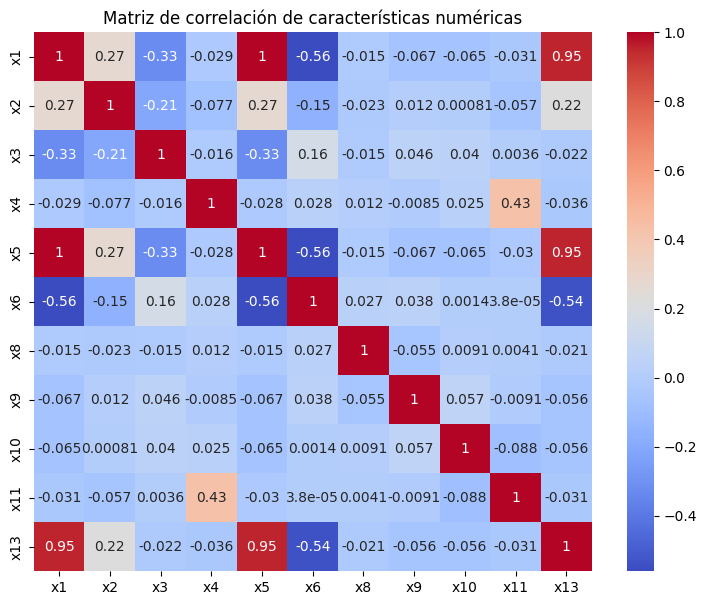

In [4]:
# Correlation Matrix (solo variables numéricas relevantes)
corr = train_df[['x1','x2','x3','x4','x5','x6','x8','x9','x10','x11','x13']].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Matriz de correlación de características numéricas')
plt.show()


### Preprocessing the data
- Drop constant column `x12`
- I drop `x5` since is highly correlated with x1.
- Handle categorical variable `x7` using One-Hot Encoding (since it’s nominal)


In [5]:
# Eliminar columna constante si existe
if 'x12' in train_df.columns:
    train_df = train_df.drop(columns=['x5','x12'])
    eval_df = eval_df.drop(columns=['x5','x12'], errors='ignore')

# Separar atributos y etiqueta
X = train_df.drop(columns=['y'])
y = train_df['y']

# One-hot encoding para x7
if 'x7' in X.columns:
    X = pd.get_dummies(X, columns=['x7'])
    eval_df = pd.get_dummies(eval_df, columns=['x7'])

# Alinear columnas entre training y evaluation
X, eval_df = X.align(eval_df, join='left', axis=1, fill_value=0)

train_df.head()



,y,x1,x2,x3,x4,x6,x7,x8,x9,x10,x11,x13
0,Jorgsuto,99.62776,-0.74730,-106.04085,-1.21694,-88.84034,Slängpolskorgris,1.36603,2.62967,12.17710,-3.38007,445.11836
1,Andjorg,100.22296,0.85161,-98.91119,-1.23724,-89.88662,Polkagris,-2.23901,0.65370,10.72266,-2.38136,451.65919
2,Andsuto,100.12711,0.22396,-96.58029,-1.18725,-89.18542,Polkagris,0.38295,-0.58657,12.60082,-1.28045,452.34540
3,Jorgsuto,100.81843,0.02120,-102.78871,-1.26271,-92.00700,Polkagris,-0.28207,0.81744,13.57450,0.12083,452.69780
4,Jorgsuto,101.07489,1.18863,-101.29639,-1.23077,-92.83613,Schottisgris,1.31717,0.69887,12.50238,-0.71997,454.72627


In [6]:
X.head()

,x1,x2,x3,x4,x6,x8,x9,x10,x11,x13,x7_Hambogris,x7_Polkagris,x7_Polskorgris,x7_Schottisgris,x7_Slängpolskorgris
0,99.62776,-0.74730,-106.04085,-1.21694,-88.84034,1.36603,2.62967,12.17710,-3.38007,445.11836,False,False,False,False,True
1,100.22296,0.85161,-98.91119,-1.23724,-89.88662,-2.23901,0.65370,10.72266,-2.38136,451.65919,False,True,False,False,False
2,100.12711,0.22396,-96.58029,-1.18725,-89.18542,0.38295,-0.58657,12.60082,-1.28045,452.34540,False,True,False,False,False
3,100.81843,0.02120,-102.78871,-1.26271,-92.00700,-0.28207,0.81744,13.57450,0.12083,452.69780,False,True,False,False,False
4,101.07489,1.18863,-101.29639,-1.23077,-92.83613,1.31717,0.69887,12.50238,-0.71997,454.72627,False,False,False,True,False


In [7]:
eval_df.head()

,x1,x2,x3,x4,x6,x8,x9,x10,x11,x13,x7_Hambogris,x7_Polkagris,x7_Polskorgris,x7_Schottisgris,x7_Slängpolskorgris
0,99.34096,-0.67540,-96.38556,-1.19631,-86.16157,0.62378,0.42649,12.10197,3.43177,448.51202,False,False,False,False,True
1,100.60896,0.18439,-102.61094,-1.23638,-93.29574,0.74169,0.25590,11.12800,-3.63810,451.73934,False,True,False,False,False
2,100.10018,0.48681,-101.76163,-1.25433,-91.08115,-1.75279,0.76439,12.83530,-0.52512,449.62008,False,True,False,False,False
3,100.01433,0.80652,-96.01828,-1.22024,-90.82540,0.37051,0.75879,9.54447,0.20145,452.06249,False,True,False,False,False
4,99.09649,0.65778,-100.90883,-1.20198,-86.97312,-1.52795,-0.49527,11.04676,1.36818,445.02802,False,False,False,False,True


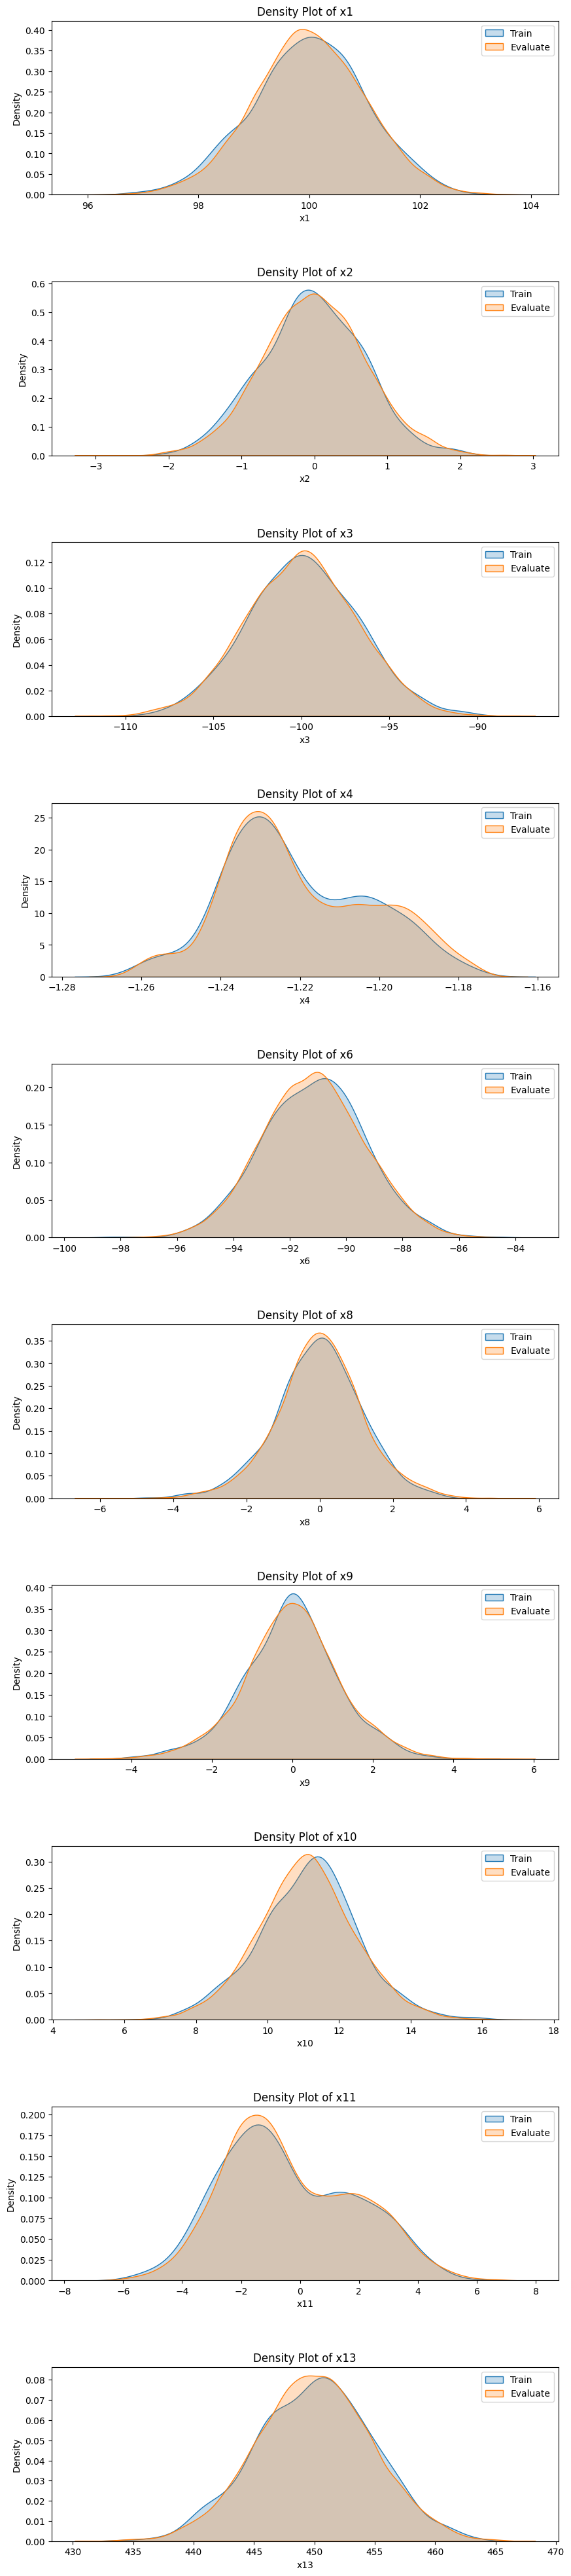

In [8]:
#¿Siguen la misma distribución las variables de entrenamiento y de test?
import matplotlib.pyplot as plt
import seaborn as sns

variables_to_plot = ['x1','x2','x3','x4','x6','x8','x9','x10','x11','x13']

# Crear subplots para cada variable
fig, axes = plt.subplots(len(variables_to_plot), 1, figsize=(10, 5 * len(variables_to_plot)))
plt.subplots_adjust(hspace=0.5) # Ajustar espacio entre subplots

for i, var in enumerate(variables_to_plot):
    sns.kdeplot(train_df[var], ax=axes[i], label='Train', fill=True)
    sns.kdeplot(eval_df[var], ax=axes[i], label='Evaluate', fill=True)
    axes[i].set_title(f'Density Plot of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.show()

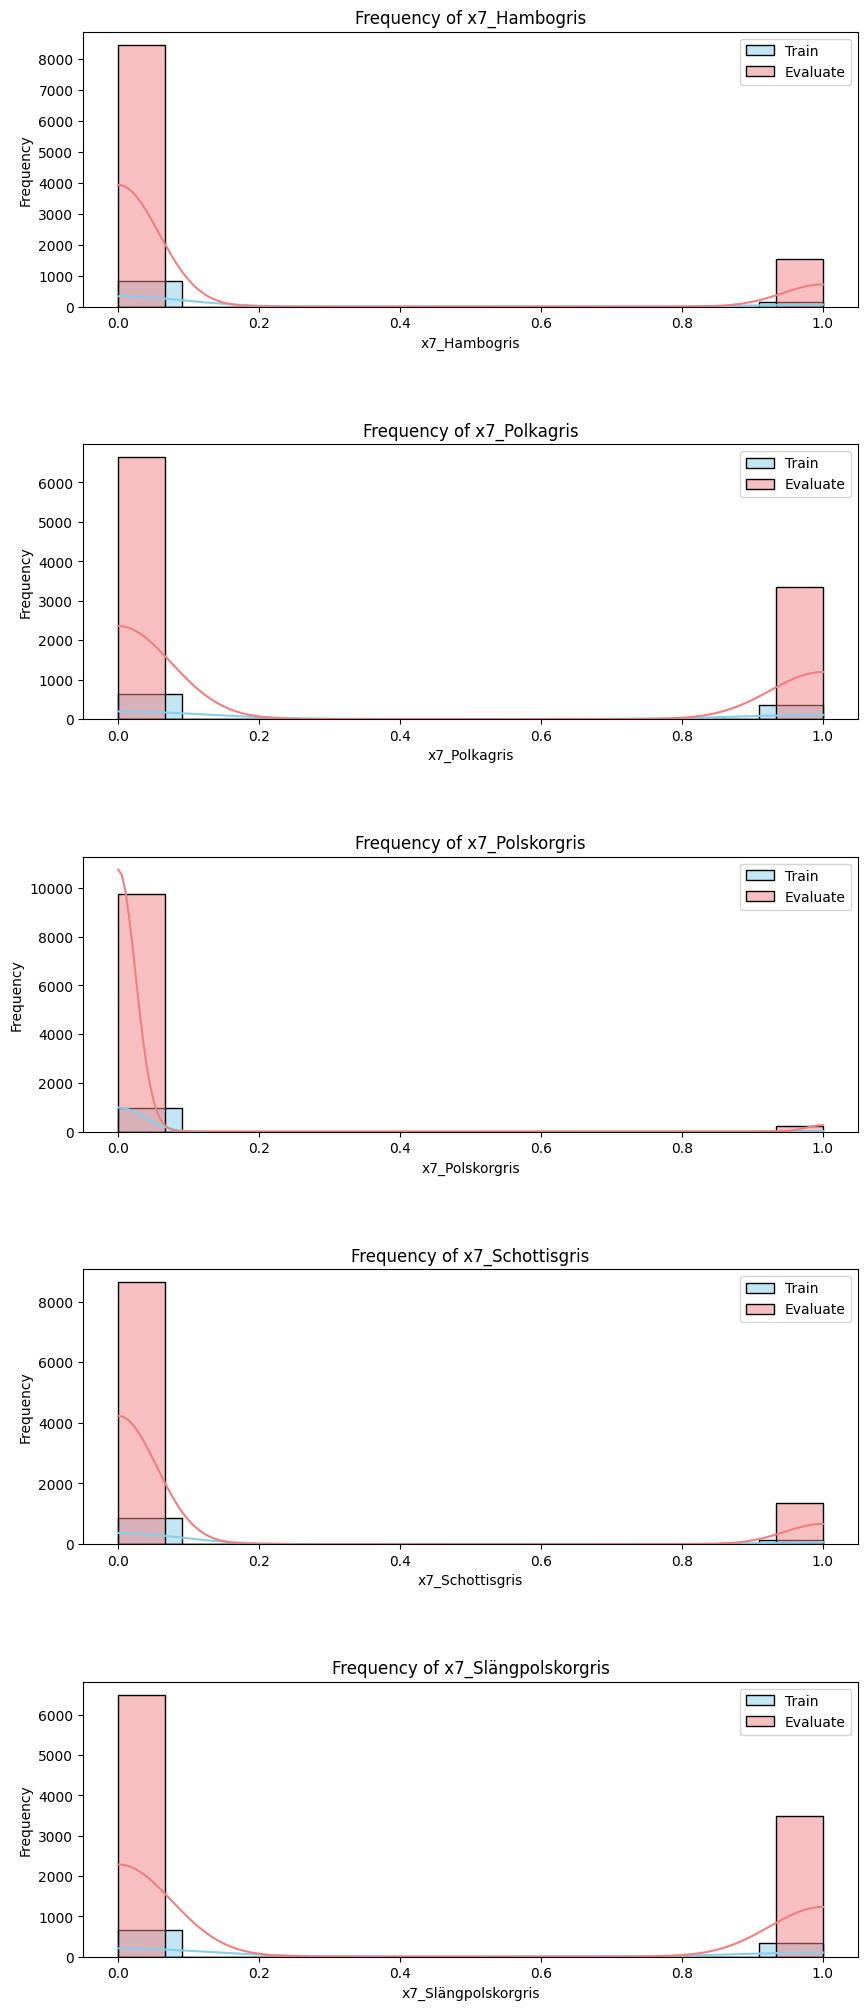

In [9]:
#Comparo las distribuciones de las variables boolean (x si hay mucho desvalance entre test y training data)
# me fijo en la proporción
import matplotlib.pyplot as plt
import seaborn as sns

variables_to_plot = ['x7_Hambogris', 'x7_Polkagris', 'x7_Polskorgris', 'x7_Schottisgris', 'x7_Slängpolskorgris']

# Create subplots for each variable
fig, axes = plt.subplots(len(variables_to_plot), 1, figsize=(10, 5 * len(variables_to_plot)))
plt.subplots_adjust(hspace=0.5) # Adjust space between subplots

for i, var in enumerate(variables_to_plot):
    sns.histplot(data=X, x=var, ax=axes[i], label='Train', color='skyblue', kde=True)
    sns.histplot(data=eval_df, x=var, ax=axes[i], label='Evaluate', color='lightcoral', kde=True)
    axes[i].set_title(f'Frequency of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.show()

#Preparamos el entrenamiento

In [10]:
# Codificar clases

le = LabelEncoder()
y_encoded = le.fit_transform(y)

##Preparamos la validación de pliegues

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### XGBoost Model

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier


# Configurar modelo con parámetros básicos para reducir overfitting
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=100,
    max_depth=5,
    subsample=0.8,
    learning_rate=0.1
)

# Cross-validation para ver performance real
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy')
print("Accuracy promedio CV:", cv_scores.mean())
print("Accuracy por fold:", cv_scores)

# Predicciones combinadas para classification report
y_pred_cv = cross_val_predict(model, X, y_encoded, cv=cv)
print("\nClassification Report (CV):")
print(classification_report(y_encoded, y_pred_cv, target_names=le.classes_))


Accuracy promedio CV: 0.849
Accuracy por fold: [0.855 0.835 0.86  0.865 0.83 ]

Classification Report (CV):
              precision    recall  f1-score   support

     Andjorg       0.85      0.92      0.88       409
     Andsuto       0.89      0.92      0.90       334
    Jorgsuto       0.78      0.64      0.70       257

    accuracy                           0.85      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.85      0.85      0.84      1000



## Entrenar y evaluar Red Neuronal con Keras

In [13]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Configurar validación cruzada (ya definida como 'cv')

# Lista para almacenar los resultados de accuracy de cada fold
cv_scores_keras = []

# Convertir columnas booleanas a float antes de convertir a numpy array
X_numeric = X.astype(float) #lo q ya era numrico no lo toca
X_np = X_numeric.values
y_encoded_np = y_encoded

# Iterar sobre los folds
for train_index, val_index in cv.split(X_np, y_encoded_np):
    X_train, X_val = X_np[train_index], X_np[val_index]
    y_train, y_val = y_encoded_np[train_index], y_encoded_np[val_index]

    # Estandarizar solo las columnas numéricas (excluyendo las one-hot encoded booleanas) OJO
    # Identificar columnas numéricas originales (asumiendo que las primeras columnas son numéricas)
    num_cols = ['x1','x2','x3','x4','x6','x8','x9','x10','x11','x13'] # Ajustar si es necesario

    scaler = StandardScaler()
    X_train_scaled_numeric = scaler.fit_transform(X_train[:, :len(num_cols)])
    X_val_scaled_numeric = scaler.transform(X_val[:, :len(num_cols)])

    # Combinar las columnas numéricas escaladas con las columnas booleanas (que ya son 0s/1s)
    X_train_scaled = np.hstack((X_train_scaled_numeric, X_train[:, len(num_cols):]))
    X_val_scaled = np.hstack((X_val_scaled_numeric, X_val[:, len(num_cols):]))


    # Configurar el modelo de Keras dentro del bucle para asegurar que se reinicia en cada fold
    num_classes = len(np.unique(y_encoded_np))
    keras_model = Sequential()
    keras_model.add(Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    keras_model.add(Dense(10, activation='relu'))
    keras_model.add(Dense(10, activation='relu'))
    keras_model.add(Dense(num_classes, activation='softmax'))

    keras_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

    # Entrenar el modelo en el fold actual
    # Utilizar un número pequeño de épocas para el ejemplo, ajustar según necesidad
    keras_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0) # verbose=0 para no mostrar el progreso

    # Evaluar el modelo en el conjunto de validación del fold
    loss, accuracy = keras_model.evaluate(X_val_scaled, y_val, verbose=0)
    cv_scores_keras.append(accuracy)

# Calcular y mostrar resultados
mean_accuracy_keras = np.mean(cv_scores_keras)
std_accuracy_keras = np.std(cv_scores_keras)

print(f"Keras Neural Network Classifier (with Standardization):")
print(f"  Accuracy promedio CV: {mean_accuracy_keras:.4f}")
print(f"  Desviación estándar CV: {std_accuracy_keras:.4f}")


/Users/martaguzman/anaconda3/envs/wfdb_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/martaguzman/anaconda3/envs/wfdb_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/martaguzman/anaconda3/envs/wfdb_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

Keras Neural Network Classifier (with Standardization):
  Accuracy promedio CV: 0.8090
  Desviación estándar CV: 0.0159


## Entrenar y evaluar Naive Bayes

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
import numpy as np

numerical_cols = ['x1','x2','x3','x4','x6','x8','x9','x10','x11','x13']  # no inlcuyo x7 pues es booleana

# Configurar clasificador Naive Bayes (GaussianNB adecuado para datos continuos/booleanos)
nb_model = GaussianNB()

# Realizar cross-validation
cv_scores_nb = cross_val_score(nb_model, X[numerical_cols], y_encoded, cv=cv, scoring='accuracy')

# Calcular y mostrar resultados
mean_accuracy_nb = np.mean(cv_scores_nb)
std_accuracy_nb = np.std(cv_scores_nb)

print(f"Naive Bayes Classifier (GaussianNB):")
print(f"  Accuracy promedio CV: {mean_accuracy_nb:.4f}")
print(f"  Desviación estándar CV: {std_accuracy_nb:.4f}")

Naive Bayes Classifier (GaussianNB):
  Accuracy promedio CV: 0.8510
  Desviación estándar CV: 0.0203


## Entrenar y evaluar Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Configurar clasificador
rf_model = RandomForestClassifier(n_estimators=1000, criterion = 'log_loss', random_state=42)

# Realizar cross-validation
cv_scores_rf = cross_val_score(rf_model, X, y_encoded, cv=cv, scoring='accuracy')

# Calcular y mostrar resultados
mean_accuracy_rf = np.mean(cv_scores_rf)
std_accuracy_rf = np.std(cv_scores_rf)

print(f"Random Forest Classifier:")
print(f"  Accuracy promedio CV: {mean_accuracy_rf:.4f}")
print(f"  Desviación estándar CV: {std_accuracy_rf:.4f}")

Random Forest Classifier:
  Accuracy promedio CV: 0.8390
  Desviación estándar CV: 0.0097


## Entrenar y evaluar Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Configurar clasificador
dt_model = DecisionTreeClassifier(random_state=42)

# Realizar cross-validation
cv_scores_dt = cross_val_score(dt_model, X, y_encoded, cv=cv, scoring='accuracy')

# Calcular y mostrar resultados
mean_accuracy_dt = np.mean(cv_scores_dt)
std_accuracy_dt = np.std(cv_scores_dt)

print(f"Decision Tree Classifier:")
print(f"  Accuracy promedio CV: {mean_accuracy_dt:.4f}")
print(f"  Desviación estándar CV: {std_accuracy_dt:.4f}")

Decision Tree Classifier:
  Accuracy promedio CV: 0.7900
  Desviación estándar CV: 0.0228


### Classificador Gaussiano y Bernoulli mixto

In [17]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd

# Identify numerical and boolean columns
numerical_cols = ['x1','x2','x3','x4','x6','x8','x9','x10','x11','x13']
boolean_cols = ['x7_Hambogris', 'x7_Polkagris', 'x7_Polskorgris', 'x7_Schottisgris', 'x7_Slängpolskorgris']

# Custom Naive Bayes with GMM for numerical features and BernoulliNB for boolean features
class MixedNaiveBayes:
    def __init__(self, n_components_gmm=1): # Changed to 1 component as requested
        self.n_components_gmm = n_components_gmm
        self.gmm_models = {}
        self.bnb_model = BernoulliNB()
        self.classes_ = None
        self.numerical_cols = numerical_cols
        self.boolean_cols = boolean_cols

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        X_num = X[self.numerical_cols]
        X_bool = X[self.boolean_cols]

        # Fit GMM for numerical features for each class
        for class_label in self.classes_:
            X_num_class = X_num[y == class_label]
            # Use GaussianMixture with the specified number of components
            gmm = GaussianMixture(n_components=self.n_components_gmm, random_state=42)
            # Handle cases where a class might have fewer samples than n_components
            if X_num_class.shape[0] < self.n_components_gmm:
                 # Fallback or handle appropriately, e.g., use fewer components or a simpler model
                 # For now, let's fit with whatever data is available, GMM might issue warnings
                 pass # GMM fit handles small sample sizes to some extent
            gmm.fit(X_num_class)
            self.gmm_models[class_label] = gmm


        # Fit BernoulliNB for boolean features
        self.bnb_model.fit(X_bool, y)

    def predict_proba(self, X):
        X_num = X[self.numerical_cols]
        X_bool = X[self.boolean_cols]

        proba = np.zeros((X.shape[0], len(self.classes_)))

        # Calculate log probabilities from GMM and BernoulliNB
        log_proba_gmm = np.zeros((X.shape[0], len(self.classes_)))
        for i, class_label in enumerate(self.classes_):
            # Ensure the GMM model was fitted for this class
            if class_label in self.gmm_models:
                log_proba_gmm[:, i] = self.gmm_models[class_label].score_samples(X_num) # score_samples returns log-likelihood
            else:
                # Handle case where GMM was not fitted (e.g., class not in training data)
                log_proba_gmm[:, i] = -np.inf # Assign very low probability


        log_proba_bnb = self.bnb_model.predict_log_proba(X_bool)

        # Combine log probabilities (equivalent to multiplying probabilities)
        # Add a small constant to avoid log(0) if needed, but GMM and BernoulliNB handle this
        combined_log_proba = log_proba_gmm + log_proba_bnb

        # Convert log probabilities back to probabilities (using softmax for numerical stability)
        # The sum of log probabilities is equivalent to the log of the product of probabilities.
        # To get the actual probability, we can exponentiate and normalize.
        # Softmax is a numerically stable way to do this.
        exp_proba = np.exp(combined_log_proba - np.max(combined_log_proba, axis=1, keepdims=True))
        proba = exp_proba / np.sum(exp_proba, axis=1, keepdims=True)


        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


# Configure combined Naive Bayes classifier with GMM (1 component) for numerical features
gmm_nb_model = MixedNaiveBayes(n_components_gmm=1) # Specify 1 component

# We need to manually perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gmm_nb = []

# Ensure X is a pandas DataFrame for column selection
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X, columns=numerical_cols + boolean_cols)


for train_index, val_index in cv.split(X, y_encoded):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # Train the custom MixedNaiveBayes model
    gmm_nb_model.fit(X_train, y_train)

    # Get predictions on the validation fold
    y_pred_val = gmm_nb_model.predict(X_val)

    # Calculate accuracy for the fold
    accuracy = accuracy_score(y_val, y_pred_val)
    cv_scores_gmm_nb.append(accuracy)

# Calculate and show results
mean_accuracy_gmm_nb = np.mean(cv_scores_gmm_nb)
std_accuracy_gmm_nb = np.std(cv_scores_gmm_nb)

print(f"Combined Naive Bayes Classifier (GMM (1 component) for Numerical + BernoulliNB for Boolean):")
print(f"  Accuracy promedio CV: {mean_accuracy_gmm_nb:.4f}")
print(f"  Desviación estándar CV: {std_accuracy_gmm_nb:.4f}")

Combined Naive Bayes Classifier (GMM (1 component) for Numerical + BernoulliNB for Boolean):
  Accuracy promedio CV: 0.8660
  Desviación estándar CV: 0.0111


## Comparación de Resultados

In [18]:
import pandas as pd

# Recopilar los resultados
results = {
    'Classifier': ['Decision Tree', 'Random Forest', 'XGBoost', 'Naive Bayes (GaussianNB)', 'Keras Neural Network (with Standardization)', 'Naive Bayes (GMM + BernoulliNB)'],
    'Mean Accuracy (CV)': [mean_accuracy_dt, mean_accuracy_rf, cv_scores.mean(), mean_accuracy_nb, mean_accuracy_keras, mean_accuracy_gmm_nb],
    'Std Dev Accuracy (CV)': [std_accuracy_dt, std_accuracy_rf, cv_scores.std(), std_accuracy_nb, std_accuracy_keras, std_accuracy_gmm_nb]
}

results_df = pd.DataFrame(results)

# Mostrar la tabla
print("Tabla Comparativa de Resultados de Clasificadores:")
display(results_df.round(4))

Tabla Comparativa de Resultados de Clasificadores:


,Classifier,Mean Accuracy (CV),Std Dev Accuracy (CV)
0,Decision Tree,0.790,0.0228
1,Random Forest,0.839,0.0097
2,XGBoost,0.849,0.0139
3,Naive Bayes (GaussianNB),0.851,0.0203
4,Keras Neural Network (with Standardization),0.809,0.0159
5,Naive Bayes (GMM + BernoulliNB),0.866,0.0111


In [19]:
"""
Cross-validation → evalúa performance y compara modelos.
fit del mejor modelo → aprovecha toda la información disponible, listo para producció.
Accuracy = 1 en entrenamiento final no importa, lo importante es que CV y test independiente indiquen performance real.

Dataset: 1000 muestras
5-fold CV: cada modelo ve 800 muestras y valida en 200.
Accuracy promedio CV: 85% (Si lo usas en un test independiente, esperas que su performance sea aproximadamente 85%, como indicó CV.)
Ahora, el modelo final ve las 1000 muestras → puede aprender patrones que no estaban completos en los folds → estará más completo.
"""

'\nCross-validation → evalúa performance y compara modelos.\nfit del mejor modelo → aprovecha toda la información disponible, listo para producció.\nAccuracy = 1 en entrenamiento final no importa, lo importante es que CV y test independiente indiquen performance real.\n\nDataset: 1000 muestras\n5-fold CV: cada modelo ve 800 muestras y valida en 200.\nAccuracy promedio CV: 85% (Si lo usas en un test independiente, esperas que su performance sea aproximadamente 85%, como indicó CV.)\nAhora, el modelo final ve las 1000 muestras → puede aprender patrones que no estaban completos en los folds → estará más completo.\n'

In [20]:
# Entrenar el mejor modelo model en todo el conjunto de datos de entrenamiento
best_model =gmm_nb_model

# Asegurarse de que X es un DataFrame de pandas para la selección de columnas
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X, columns=numerical_cols + boolean_cols) # Assuming numerical_cols and boolean_cols are defined

best_model.fit(X, y_encoded)

# Realizar predicciones en el conjunto de datos de evaluación (eval_df)
# Asegurarse de que eval_df tiene las mismas columnas y orden que X
# Esto ya se manejó en el preprocesamiento con X.align(eval_df, ...)
y_pred_encoded = best_model.predict(eval_df)

# Convertir las predicciones codificadas de vuelta a las etiquetas originales
y_pred_labels = le.inverse_transform(y_pred_encoded)

# Guardar las predicciones en un archivo de texto, una predicción por línea
output_filename = "gmm_nb_predictions.txt"
np.savetxt(output_filename, y_pred_labels, fmt='%s')

print(f"Predicciones guardadas en '{output_filename}'")

Predicciones guardadas en 'gmm_nb_predictions.txt'
